# Customer Segmentation — Phase 2: K-Means Clustering
Mall Customers Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
import warnings
warnings.filterwarnings("ignore")
 
plt.rcParams.update({"figure.facecolor": "white", "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True,
                     "grid.color": "#e5e5e5"})
 
SEED = 42
# Cluster colours — 5 distinct, colourblind-friendly
CLUSTER_COLORS = ["#4C72B0", "#E07070", "#2ca02c", "#FF7F0E", "#9467BD"]

LOAD & PREPARE DATA

In [2]:
df = pd.read_csv("Mall_Customers.csv")
df.columns = df.columns.str.strip()
df.rename(columns={
    "Genre"                 : "Gender",
    "Annual Income (k$)"    : "AnnualIncome",
    "Spending Score (1-100)": "SpendingScore",
}, inplace=True)
 
print("=" * 55)
print("PHASE 2 — K-MEANS CLUSTERING")
print("=" * 55)
print(f"Dataset: {df.shape[0]} customers, {df.shape[1]} columns")
 
# We cluster on Income + Spending Score — the two features that showed
# clear visual separation in the Phase 1 pairplot.
# Age is included in a second run for comparison.
X_2d = df[["AnnualIncome", "SpendingScore"]].values
X_3d = df[["Age", "AnnualIncome", "SpendingScore"]].values
 
# Scale — K-Means uses Euclidean distance, so unscaled income (15–137)
# would dominate spending score (1–100) without this step.
scaler_2d = StandardScaler()
scaler_3d = StandardScaler()
X_2d_scaled = scaler_2d.fit_transform(X_2d)
X_3d_scaled = scaler_3d.fit_transform(X_3d)
 
print(f"\nFeature spaces:")
print(f"  2D: AnnualIncome + SpendingScore  (primary)")
print(f"  3D: Age + AnnualIncome + SpendingScore  (extended)")
print(f"\nScaling applied: StandardScaler (zero mean, unit variance)")
print(f"  Income range before scaling : {X_2d[:,0].min():.0f} – {X_2d[:,0].max():.0f}")
print(f"  Income range after  scaling : {X_2d_scaled[:,0].min():.2f} – {X_2d_scaled[:,0].max():.2f}")

PHASE 2 — K-MEANS CLUSTERING
Dataset: 200 customers, 5 columns

Feature spaces:
  2D: AnnualIncome + SpendingScore  (primary)
  3D: Age + AnnualIncome + SpendingScore  (extended)

Scaling applied: StandardScaler (zero mean, unit variance)
  Income range before scaling : 15 – 137
  Income range after  scaling : -1.74 – 2.92


ELBOW METHOD

In [3]:
K_RANGE  = range(1, 11)
inertias = []
 
for k in K_RANGE:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=SEED)
    km.fit(X_2d_scaled)
    inertias.append(km.inertia_)
 
print(f"\nElbow method — inertia by k:")
print(f"{'k':>4}  {'Inertia':>10}  {'Drop %':>8}")
print("-" * 28)
for i, (k, inertia) in enumerate(zip(K_RANGE, inertias)):
    drop = (inertias[i-1] - inertia) / inertias[i-1] * 100 if i > 0 else 0
    marker = "  ← elbow" if 4 <= k <= 6 else ""
    print(f"  {k:>2}  {inertia:>10.1f}  {drop:>7.1f}%{marker}")


Elbow method — inertia by k:
   k     Inertia    Drop %
----------------------------
   1       400.0      0.0%
   2       269.7     32.6%
   3       157.7     41.5%
   4       108.9     30.9%  ← elbow
   5        65.6     39.8%  ← elbow
   6        55.1     16.0%  ← elbow
   7        44.9     18.5%
   8        37.2     17.0%
   9        32.4     13.0%
  10        30.0      7.4%


SILHOUETTE SCORES

In [4]:
 
#    Silhouette score: how similar each point is to its own cluster vs others
#    Range: -1 (wrong cluster) to +1 (perfect cluster)
#    Peak score confirms the optimal k from the elbow method
# ════════════════════════════════════════════════════════════════════════════
 
sil_scores = []
 
for k in range(2, 11):   # silhouette needs k >= 2
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=SEED)
    labels = km.fit_predict(X_2d_scaled)
    sil_scores.append(silhouette_score(X_2d_scaled, labels))
 
best_k   = np.argmax(sil_scores) + 2   # offset by 2 (range starts at 2)
best_sil = max(sil_scores)
 
print(f"\nSilhouette scores (k=2..10):")
print(f"{'k':>4}  {'Silhouette':>12}")
print("-" * 20)
for k, s in zip(range(2, 11), sil_scores):
    marker = "  ← best" if k == best_k else ""
    print(f"  {k:>2}  {s:>12.4f}{marker}")
print(f"\nOptimal k = {best_k}  (silhouette = {best_sil:.4f})")


Silhouette scores (k=2..10):
   k    Silhouette
--------------------
   2        0.3213
   3        0.4666
   4        0.4939
   5        0.5547  ← best
   6        0.5399
   7        0.5281
   8        0.4552
   9        0.4571
  10        0.4432

Optimal k = 5  (silhouette = 0.5547)


ELBOW + SILHOUETTE PLOT

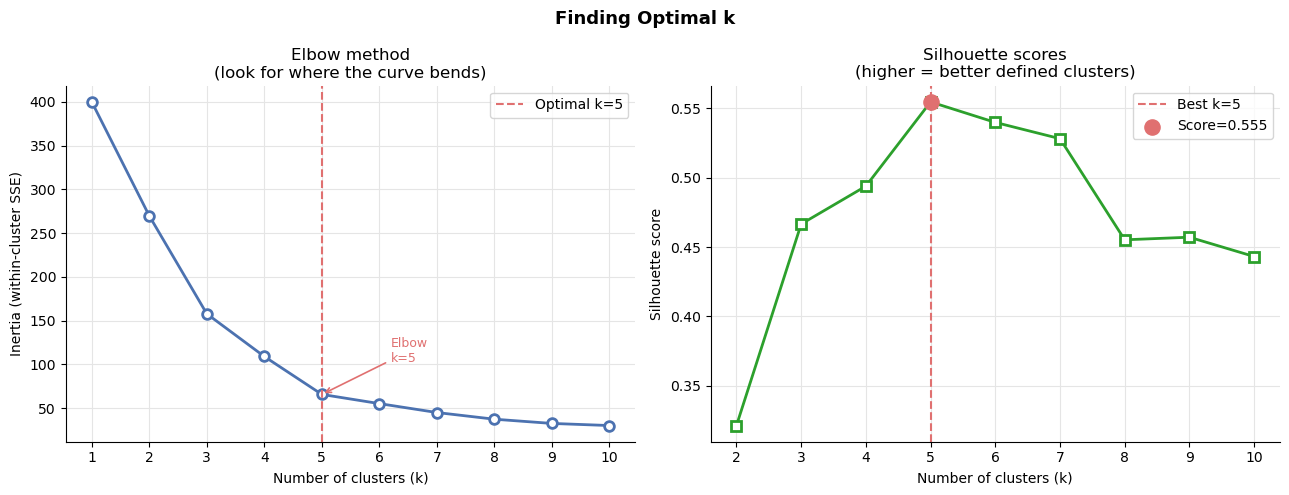

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Finding Optimal k", fontweight="bold", fontsize=13)
 
# Panel 1: Elbow
ax = axes[0]
ax.plot(list(K_RANGE), inertias, marker="o", color="#4C72B0",
        linewidth=2, markersize=7, markerfacecolor="white",
        markeredgewidth=2)
ax.axvline(best_k, color="#E07070", linestyle="--",
           linewidth=1.5, label=f"Optimal k={best_k}")
ax.set_xlabel("Number of clusters (k)")
ax.set_ylabel("Inertia (within-cluster SSE)")
ax.set_title("Elbow method\n(look for where the curve bends)")
ax.set_xticks(list(K_RANGE))
ax.legend(fontsize=10)
 
# Annotate elbow
ax.annotate(f"Elbow\nk={best_k}",
            xy=(best_k, inertias[best_k-1]),
            xytext=(best_k+1.2, inertias[best_k-1] + (inertias[0]-inertias[-1])*0.1),
            fontsize=9, color="#E07070",
            arrowprops=dict(arrowstyle="->", color="#E07070", lw=1.2))
 
# Panel 2: Silhouette
ax2 = axes[1]
ax2.plot(list(range(2, 11)), sil_scores, marker="s", color="#2ca02c",
         linewidth=2, markersize=7, markerfacecolor="white",
         markeredgewidth=2)
ax2.axvline(best_k, color="#E07070", linestyle="--",
            linewidth=1.5, label=f"Best k={best_k}")
ax2.scatter([best_k], [best_sil], s=120, color="#E07070",
            zorder=5, label=f"Score={best_sil:.3f}")
ax2.set_xlabel("Number of clusters (k)")
ax2.set_ylabel("Silhouette score")
ax2.set_title("Silhouette scores\n(higher = better defined clusters)")
ax2.set_xticks(list(range(2, 11)))
ax2.legend(fontsize=10)
 
plt.tight_layout()
plt.savefig("phase2_elbow_silhouette.png", dpi=150, bbox_inches="tight")
plt.show()
 

 FIT FINAL MODEL

In [6]:
km_final = KMeans(n_clusters=best_k, init="k-means++",
                  n_init=10, random_state=SEED)
df["Cluster"] = km_final.fit_predict(X_2d_scaled)
 
# Centroids — inverse transform back to original scale
centroids_scaled = km_final.cluster_centers_
centroids_real   = scaler_2d.inverse_transform(centroids_scaled)
centroids_df     = pd.DataFrame(centroids_real,
                                columns=["AnnualIncome", "SpendingScore"])
centroids_df.index.name = "Cluster"
 
print(f"\nFinal model fitted: k={best_k}")
print(f"\nCluster sizes:")
print(df["Cluster"].value_counts().sort_index().to_string())
print(f"\nCluster centroids (original scale):")
print(centroids_df.round(1).to_string())


Final model fitted: k=5

Cluster sizes:
Cluster
0    81
1    39
2    22
3    35
4    23

Cluster centroids (original scale):
         AnnualIncome  SpendingScore
Cluster                             
0                55.3           49.5
1                86.5           82.1
2                25.7           79.4
3                88.2           17.1
4                26.3           20.9


CLUSTER SCATTER PLOT

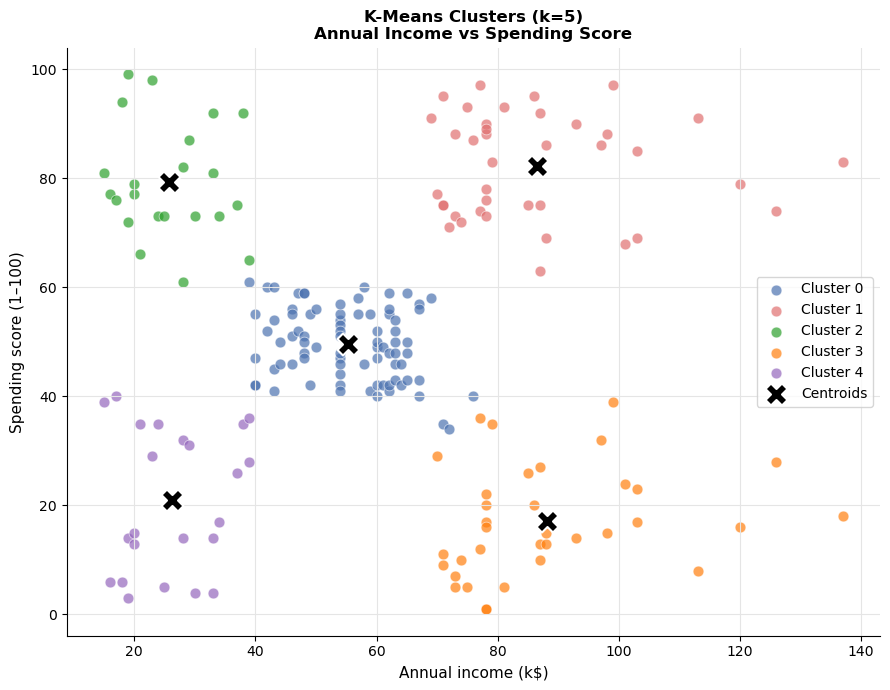

In [7]:
fig, ax = plt.subplots(figsize=(9, 7))
 
for cluster_id in range(best_k):
    mask   = df["Cluster"] == cluster_id
    color  = CLUSTER_COLORS[cluster_id]
    subset = df[mask]
    ax.scatter(subset["AnnualIncome"], subset["SpendingScore"],
               s=60, color=color, alpha=0.7, edgecolors="white",
               linewidth=0.5, label=f"Cluster {cluster_id}")
 
# Plot centroids
ax.scatter(centroids_df["AnnualIncome"], centroids_df["SpendingScore"],
           s=250, color="black", marker="X", zorder=5,
           edgecolors="white", linewidth=1.5, label="Centroids")
 
ax.set_xlabel("Annual income (k$)", fontsize=11)
ax.set_ylabel("Spending score (1–100)", fontsize=11)
ax.set_title(f"K-Means Clusters (k={best_k})\nAnnual Income vs Spending Score",
             fontweight="bold")
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("phase2_cluster_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
 

SILHOUETTE PLOT — PER SAMPLE

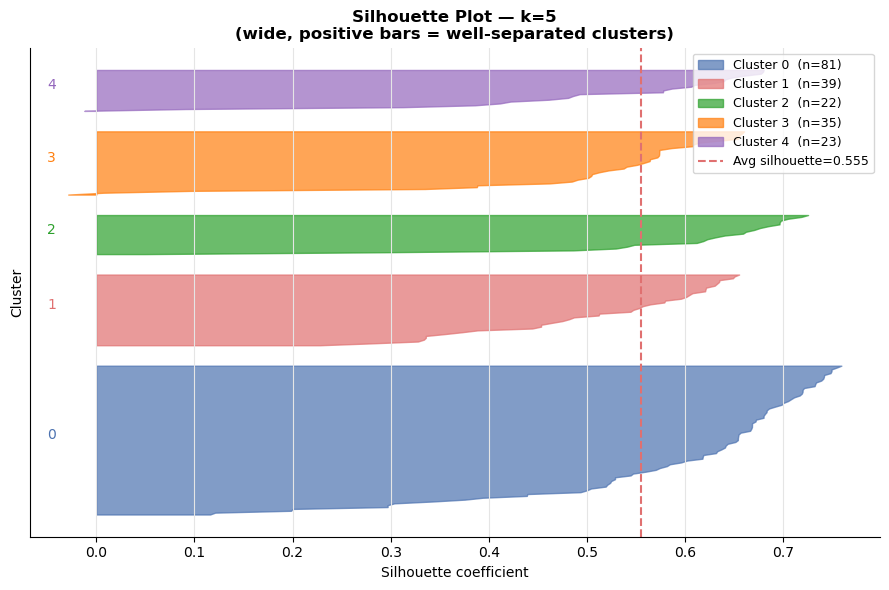

In [8]:

#    Shows how well each point fits its assigned cluster

 
sil_vals    = silhouette_samples(X_2d_scaled, df["Cluster"])
df["SilhouetteScore"] = sil_vals
 
fig, ax = plt.subplots(figsize=(9, 6))
y_lower = 10
 
for cluster_id in range(best_k):
    sil_cluster = np.sort(sil_vals[df["Cluster"] == cluster_id])
    size        = len(sil_cluster)
    y_upper     = y_lower + size
 
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, sil_cluster,
                     alpha=0.7, color=CLUSTER_COLORS[cluster_id],
                     label=f"Cluster {cluster_id}  (n={size})")
    ax.text(-0.05, y_lower + size / 2, str(cluster_id),
            fontsize=10, color=CLUSTER_COLORS[cluster_id])
    y_lower = y_upper + 10
 
ax.axvline(best_sil, color="#E07070", linestyle="--",
           linewidth=1.5, label=f"Avg silhouette={best_sil:.3f}")
ax.set_xlabel("Silhouette coefficient")
ax.set_ylabel("Cluster")
ax.set_title(f"Silhouette Plot — k={best_k}\n"
             "(wide, positive bars = well-separated clusters)",
             fontweight="bold")
ax.legend(loc="upper right", fontsize=9)
ax.set_yticks([])
plt.tight_layout()
plt.savefig("phase2_silhouette_plot.png", dpi=150, bbox_inches="tight")
plt.show()
 

CLUSTER PROFILES

In [9]:
profile = df.groupby("Cluster").agg(
    Count        =("CustomerID", "count"),
    AvgAge       =("Age", "mean"),
    AvgIncome    =("AnnualIncome", "mean"),
    AvgSpending  =("SpendingScore", "mean"),
    PctFemale    =("Gender", lambda x: (x == "Female").mean() * 100),
).round(1)
 
print(f"\nCluster profiles:")
print(profile.to_string())
 
# Save processed data for Phase 3 & 4
df.to_csv("customers_clustered.csv", index=False)
print("\nSaved: customers_clustered.csv  ← load this in Phase 3 & 4")
 
print("\n" + "=" * 55)
print("PHASE 2 SUMMARY")
print("=" * 55)
print(f"  Optimal k       : {best_k}  (elbow + silhouette agreement)")
print(f"  Silhouette score: {best_sil:.4f}")
print(f"  Algorithm       : K-Means++  (smarter initialisation)")
print(f"  Feature space   : AnnualIncome + SpendingScore (scaled)")
 
print("\nSaved:")
print("  phase2_elbow_silhouette.png")
print("  phase2_cluster_scatter.png")
print("  phase2_silhouette_plot.png")
print("  customers_clustered.csv")
print("\nNext: Phase 3 & 4 — PCA visualisation + business personas")
 


Cluster profiles:
         Count  AvgAge  AvgIncome  AvgSpending  PctFemale
Cluster                                                  
0           81    42.7       55.3         49.5       59.3
1           39    32.7       86.5         82.1       53.8
2           22    25.3       25.7         79.4       59.1
3           35    41.1       88.2         17.1       45.7
4           23    45.2       26.3         20.9       60.9

Saved: customers_clustered.csv  ← load this in Phase 3 & 4

PHASE 2 SUMMARY
  Optimal k       : 5  (elbow + silhouette agreement)
  Silhouette score: 0.5547
  Algorithm       : K-Means++  (smarter initialisation)
  Feature space   : AnnualIncome + SpendingScore (scaled)

Saved:
  phase2_elbow_silhouette.png
  phase2_cluster_scatter.png
  phase2_silhouette_plot.png
  customers_clustered.csv

Next: Phase 3 & 4 — PCA visualisation + business personas
